<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/physics_lab/Pendelum_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PENDELUM EXPERIMENT

<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3307789932.py:51: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"$g$ = {g:.1f} $\pm$ {dg:.1f} m/s$^2$", fontsize=12)


b0 =-0.037873684403715954
b1 =4.058304094461646
g =9.7278115896326
dg=0.5350067291258933
g = 9.7 +/- 0.5 m/s^2


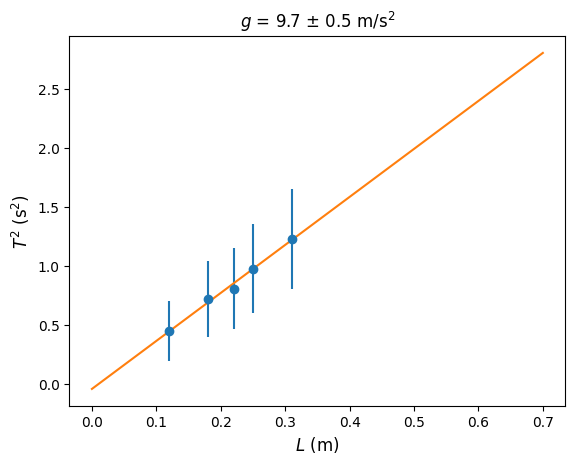

In [ ]:
from scipy import *
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

## Input data
length = np.array([0.31, 0.25, 0.22, 0.18, 0.12])
length_uncertainty = np.repeat(0.005, 5)
period = np.array([1.11, 0.99, 0.90, 0.85, 0.67])
period_uncertainty = np.repeat(0.19, 5)

# Process data (turn period [T] into T^2 to graph it later)
Tsq = period ** 2                              # Estimates for T^2
Tsq_error = 2 * period * period_uncertainty     # Errors for T^2, from error propagation

## Define an order-1 polynomial function (y = b1(x) + b0), and use it to fit the data
def f(x, b0, b1): return b0 + b1*x
est, covar = curve_fit(f, length, Tsq)

## Estimators and their errors:
b0, b1 = est                  # Estimates of intercept and slope
db0 = np.sqrt(covar[0,0])     # Standard error of intercept
db1 = np.sqrt(covar[1,1])     # Standard error of slope

print(f"b0 ={b0}") # it is good practice to check that b0 is very close to zero (it should be zero since if L=0 there will be no period)
print(f"b1 ={b1}")

# Calculation of g and its uncertainty
g = (4 * np.pi * np.pi) / b1       # Estimate for g (computed from b1)
dg = (g / b1) * db1                # Estimate for standard error of g

print(f"g ={g}")
print (f"dg={dg}")

# Round up to and describe the acceleration of gravity with the appropriate significant figures and its units.
print(f"g = {g:.1f} +/- {dg:.1f} m/s^2")

## Plot the data points, with error bars
import matplotlib.pyplot as plt
## plt.style.use('dark_background') #this puts it with a dark background. You can comment this line.

plt.errorbar(length, Tsq, xerr = length_uncertainty, yerr = Tsq_error, fmt='o')
plt.xlabel('$L$ (m)', fontsize=12)
plt.ylabel('$T^2$ (s$^2$)', fontsize=12)

# Include the fitted curve in the plot
L2 = np.linspace(0, 0.7, 100)
plt.plot(L2, b0 + b1*L2)

# State fitted value of g in the figure title
plt.title(f"$g$ = {g:.1f} $\pm$ {dg:.1f} m/s$^2$", fontsize=12)
plt.show()


FREE FALLING PARACHUTE EXPERIMENT


<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-289833554.py:52: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"$v$ = {v:.2f} $\pm$ {dv:.2f} m/s$^2$", fontsize=12)


intital height =4.3308516490101026
velocity =-1.678979172107122
v =-1.678979172107122
dv=0.029006993788494327
v = -1.7 +/- 0.0 m/s


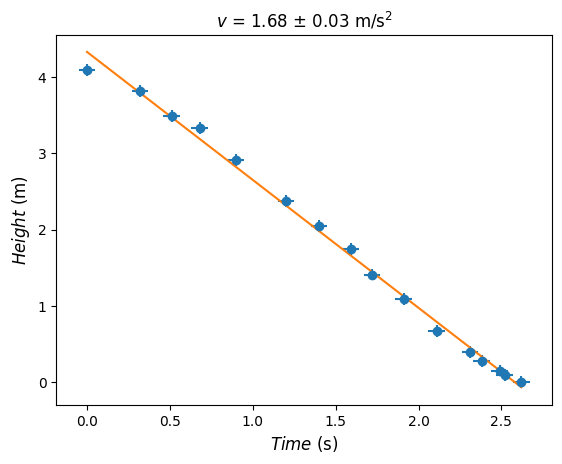

In [ ]:
from scipy import *
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

## Input data
height = np.array([4.09, 3.82, 3.49, 3.33, 2.91, 2.38, 2.05, 1.74, 1.41, 1.09, 0.67, 0.39, 0.28, 0.15, 0.09, 0.00])
height_uncertainty = np.repeat(0.0777537797, 16)
time = np.array([7.83, 8.15, 8.34, 8.51, 8.73, 9.03, 9.23, 9.42, 9.55, 9.74, 9.94, 10.14, 10.21, 10.32, 10.35, 10.45])
time_uncertainty = np.repeat(0.05, 16)

# Adjust time so that it starts from 0s instead of 7.38s
time = time - 7.83

## Define an order-1 polynomial function (y = b1(x) + b0), and use it to fit the data
## The funtion we would be using is X = Xi - v(t)
    # X is the current position
    # Xi is the initial position (and our intercept)
    # -v is our slope (and the terminal velocity)
    # t is time
def f(t, h_i, v): return h_i + v * t
est, covar = curve_fit(f, time, height)

## Estimators and their errors:
h_i, v = est                  # Estimates of intercept and slope
dh_i = np.sqrt(covar[0,0])    # Standard error of intercept
dv = np.sqrt(covar[1,1])      # Standard error of slope (terminal velocity)

print(f"intital height ={h_i}")
print(f"velocity ={v}")

print(f"v ={v}")
print (f"dv={dv}")

# Round up to and describe the acceleration of gravity with the appropriate significant figures and its units.
print(f"v = {v:.1f} +/- {dv:.1f} m/s")

## Plot the data points, with error bars
import matplotlib.pyplot as plt
## plt.style.use('dark_background') #this puts it with a dark background. You can comment this line.

plt.errorbar(time, height, xerr = time_uncertainty, yerr = height_uncertainty, fmt='o')
plt.xlabel('$Time$ (s)', fontsize=12)
plt.ylabel('$Height$ (m)', fontsize=12)

# Include the fitted curve in the plot
L2 = np.linspace(0, time.max(), 100)
plt.plot(L2, h_i + v * L2)

# State fitted value of v in the figure title
v *= -1 # Convert the velocity into positive for the title
plt.title(f"$v$ = {v:.2f} $\pm$ {dv:.2f} m/s$^2$", fontsize=12)
plt.show()
